# LSTM Trajectory Predictor


In [169]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import os

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"PyTorch: {torch.__version__}")
print(f"Device:  {device}")
os.makedirs('../models',  exist_ok=True)
os.makedirs('../results', exist_ok=True)

PyTorch: 2.11.0
Device:  mps


### Load Trajectory Data
Load positions in 2D. We drop the Z axis entirely because all users are at Z=2m (ground level) and it never changes. It only causes division-by-zero errors in normalization. Load the three `.npy` files saved in data generation.

In [170]:
def load_2d(path):
    return np.load(path, allow_pickle=True).item()['positions'][:, :2]

pos_s = load_2d('../data/trajectory_straight.npy')
pos_c = load_2d('../data/trajectory_curve.npy')
pos_t = load_2d('../data/trajectory_turn.npy')

print(f"Straight : {pos_s.shape}  first={pos_s[0]}  last={pos_s[-1]}")
print(f"Curve    : {pos_c.shape}  first={pos_c[0]}  last={pos_c[-1]}")
print(f"Turn     : {pos_t.shape}  first={pos_t[0]}  last={pos_t[-1]}")

Straight : (200, 2)  first=[260.023 299.971]  last=[260.023 599.971]
Curve    : (200, 2)  first=[260.023 299.971]  last=[259.823 598.571]
Turn     : (200, 2)  first=[260.023 299.971]  last=[277.823 499.971]


### Visualising the 3 trajectories

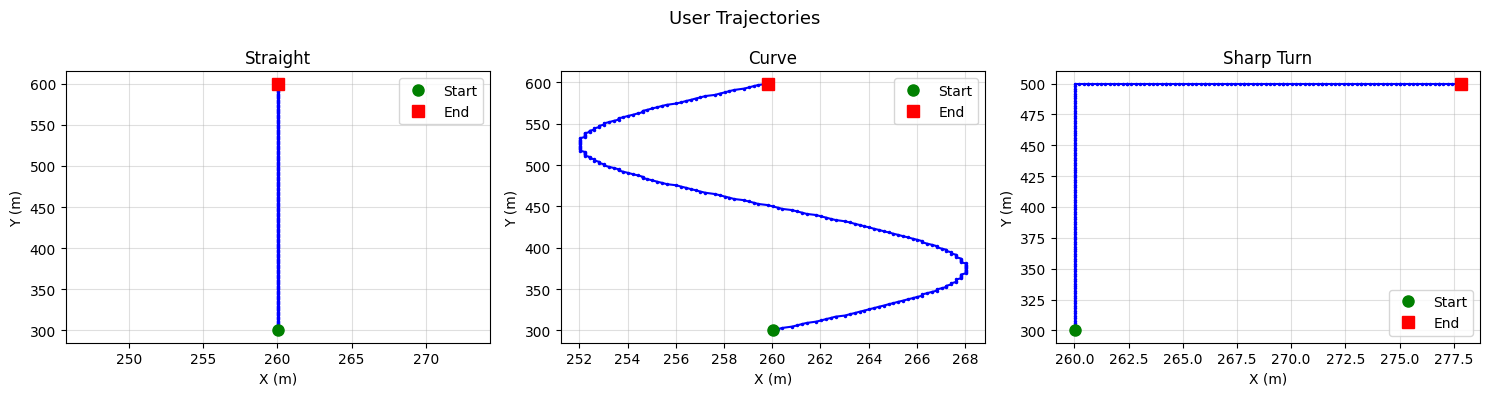

In [171]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, pos, title in zip(axes,
                           [pos_s, pos_c, pos_t],
                           ['Straight', 'Curve', 'Sharp Turn']):
    ax.plot(pos[:,0], pos[:,1], 'b.-', ms=3)
    ax.plot(pos[0,0],  pos[0,1],  'go', ms=8, label='Start')
    ax.plot(pos[-1,0], pos[-1,1], 'rs', ms=8, label='End')
    ax.set_title(title); ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
    ax.legend(); ax.grid(True, alpha=0.4)
plt.suptitle('User Trajectories', fontsize=13)
plt.tight_layout()
plt.savefig('../results/trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

### Build Sliding Windows with Local Normalization

The Y axis spans ~300m but each step is only ~1.6m.
If we normalize globally, one step = 0.005 in [0,1] space — too small for the model to learn.
To fix this, we subtract the anchor (last known position) from every window. Now inputs and target are relative displacements centred around zero. The model only needs to learn "how far do I move next" (~1.6m) not "where am I globally" (~300m range).

Build local sliding windows. For each position in the trajectory starting at index 10, we take the previous 10 positions as input and the next position as the target. The anchor is the last position in the input window (index 9 of the window). We subtract the anchor from every position in the window and from the target. This converts absolute coordinates into relative displacements.


In [ ]:
# We have 200 positions per trajectory. With 3 trajectories that's 570 samples total. 
# We need to turn these into training samples using a sliding window of size T=10.
# This means:
# Sample 1: Take positions 0 through 9 as input → predict position 10
# Sample 2: Take positions 1 through 10 as input → predict position 11
# Sample 3: Take positions 2 through 11 as input → predict position 12.....
# From 200 positions you get 190 training samples per trajectory. 

W = 10  # window size

def make_local_windows(pos):
    """
    For each window of W positions:
      anchor = pos[i+W-1]          (last known position)
      input  = pos[i:i+W] - anchor (relative: small values around 0)
      target = pos[i+W]   - anchor (relative displacement to predict)
    """
    X, y, anchors = [], [], []
    for i in range(len(pos) - W):
        anchor = pos[i + W - 1]
        X.append(pos[i:i+W] - anchor)
        y.append(pos[i+W]   - anchor)
        anchors.append(anchor)
    return np.array(X), np.array(y), np.array(anchors)

X_s, y_s, anc_s = make_local_windows(pos_s)
X_c, y_c, anc_c = make_local_windows(pos_c)
X_t, y_t, anc_t = make_local_windows(pos_t)

print(f"Points per trajectory : {len(pos_s)}")
print(f"Window size           : {W}")
print(f"Windows per trajectory: {len(pos_s) - W}")
print(f"Total windows (3 traj): {(len(pos_s) - W) * 3}")
print(f"Train windows         : {len(X_tr)}")
print(f"Val windows           : {len(X_va)}")

Points per trajectory : 200
Window size           : 10
Windows per trajectory: 190
Total windows (3 traj): 570
Train windows         : 456
Val windows           : 114


### Verifying if window-target pairing is correct

In [173]:
print(f"pos_s[9]  (anchor)     = {pos_s[9]}")
print(f"pos_s[10] (true next)  = {pos_s[10]}")
print(f"y_s[0]    (rel target) = {y_s[0]}  should be pos_s[10] - pos_s[9]")
expected = pos_s[10] - pos_s[9]
print(f"Expected               = {expected}")
print(f"Match: {np.allclose(y_s[0], expected)}")
step = np.sqrt(np.sum(y_s[0]**2))
print(f"Step magnitude: {step:.4f}m  (expected ~1.6m)")
assert np.allclose(y_s[0], expected)

pos_s[9]  (anchor)     = [260.023 313.571]
pos_s[10] (true next)  = [260.023 315.171]
y_s[0]    (rel target) = [0.        1.5999756]  should be pos_s[10] - pos_s[9]
Expected               = [0.        1.5999756]
Match: True
Step magnitude: 1.6000m  (expected ~1.6m)


### Scale Relative Values to [-1, 1]
Scale to [-1, 1]. We compute the 99th percentile of the absolute values of all relative inputs across all windows. This gives us a scale factor that handles the different step sizes across the three trajectories robustly without being thrown off by rare large displacements at the sharp turn. Dividing by this scale factor brings everything into roughly [-1, 1].

In [ ]:
# Neural networks train much better when input values are small numbers close to zero, rather than 
# raw coordinates like X=260, Y=500. Normalization rescales everything to roughly the range [0, 1]. 
# Critically, you must save the normalization parameters so you can reverse the normalization later 
# when you want actual metre coordinates back.

X_all = np.concatenate([X_s, X_c, X_t], axis=0)
y_all = np.concatenate([y_s, y_c, y_t], axis=0)

# Scale by 99th percentile of absolute relative values
# This handles the different step sizes across trajectories robustly
scale = np.percentile(np.abs(X_all), 99, axis=(0, 1))
scale = np.where(scale == 0, 1.0, scale)

print(f"Scale factors (X, Y):{scale}")
print(f"This converts each axis to roughly [-1, 1]")

def norm(x):   return x / scale
def denorm(x): return x * scale

X_norm = norm(X_all)
y_norm = norm(y_all)

print(f"\nAfter scaling:")
print(f"  X_norm range: [{X_norm.min():.4f}, {X_norm.max():.4f}]")
print(f"  y_norm range: [{y_norm.min():.4f}, {y_norm.max():.4f}]")
print(f"  Any NaN: {np.any(np.isnan(X_norm)) or np.any(np.isnan(y_norm))}")

# Roundtrip check
rt = denorm(norm(y_s[0]))
print(f"\nRoundtrip y_s[0]: {y_s[0]} → norm → denorm → {rt}")
print(f"Error: {np.max(np.abs(rt - y_s[0])):.8f}  (must be ~0)")

# Save scale
np.save('../models/norm_params.npy', {'scale': scale}, allow_pickle=True)

Scale factors (X, Y):[ 2. 18.]
This converts each axis to roughly [-1, 1]

After scaling:
  X_norm range: [-1.1000, 1.2000]
  y_norm range: [-0.2000, 0.2000]
  Any NaN: False

Roundtrip y_s[0]: [0.        1.5999756] → norm → denorm → [0.        1.5999756]
Error: 0.00000000  (must be ~0)


### Train / Validation Split
We use the first 80% of each trajectory for training and the last 20% for validation. This preserves temporal order as the model never sees future positions during training, which reflects how the system would work in real deployment.

In [175]:
n     = len(X_s)       # 190 windows per trajectory
split = int(0.8 * n)   # 152 train, 38 val

X_tr = np.concatenate([X_norm[:split],    X_norm[n:n+split],   X_norm[2*n:2*n+split]])
y_tr = np.concatenate([y_norm[:split],    y_norm[n:n+split],   y_norm[2*n:2*n+split]])
X_va = np.concatenate([X_norm[split:n],   X_norm[n+split:2*n], X_norm[2*n+split:]])
y_va = np.concatenate([y_norm[split:n],   y_norm[n+split:2*n], y_norm[2*n+split:]])

print(f"Train samples: {len(X_tr)}  |  Val samples: {len(X_va)}")

# Final check on a training sample
raw_last  = anc_s[0] + denorm(X_tr[0][-1])
raw_target= anc_s[0] + denorm(y_tr[0])
step_check= np.sqrt(np.sum((raw_target - raw_last)**2))
print(f"\nTrain[0] last input (abs): {raw_last}")
print(f"Train[0] target     (abs): {raw_target}")
print(f"Step size: {step_check:.4f}m  (must be ~1.6m)")

class TrajDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):        return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_loader = DataLoader(TrajDataset(X_tr, y_tr), batch_size=16, shuffle=True)
val_loader   = DataLoader(TrajDataset(X_va, y_va), batch_size=16, shuffle=False)
print(f"\nTrain batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")

Train samples: 456  |  Val samples: 114

Train[0] last input (abs): [260.023 313.571]
Train[0] target     (abs): [260.023 315.171]
Step size: 1.6000m  (must be ~1.6m)

Train batches: 29  |  Val batches: 8


### Define the LSTM Model

#An LSTM (Long Short-Term Memory) is a type of recurrent neural network designed to learn patterns 
#in sequences. It has a memory that carries information forward through time — so when it processes 
#position 8 in a window, it still "remembers" what positions 1–7 looked like. This is exactly what 
#you need for trajectory prediction. The architecture has three parts: an LSTM layer that processes 
#the sequence, a dropout layer that prevents overfitting (randomly turns off neurons during training to force the network to learn robust patterns), and a linear output layer that converts the LSTM's hidden state into a predicted (x, y, z) coordinate.

In [176]:
class LSTMPredictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = 64
        self.layers = 2
        self.lstm = nn.LSTM(2, 64, 2, batch_first=True, dropout=0.1)
        self.drop = nn.Dropout(0.1)
        self.fc   = nn.Linear(64, 2)

    def forward(self, x):
        h0 = torch.zeros(self.layers, x.size(0), self.hidden).to(x.device)
        c0 = torch.zeros(self.layers, x.size(0), self.hidden).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        return self.fc(self.drop(out[:, -1, :]))

model     = LSTMPredictor().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=20)

print(f"Parameters: {sum(p.numel() for p in model.parameters())}")

# Sanity check — untrained model output should be small random values
model.eval()
with torch.no_grad():
    t_out = model(torch.tensor(X_tr[:1], dtype=torch.float32).to(device)).cpu().numpy()[0]
print(f"\nUntrained output (relative metres): {denorm(t_out)}")
print(f"Expected target  (relative metres): {denorm(y_tr[0])}")
print("(Both should be small values, ~0-2m range)")

Parameters: 50818

Untrained output (relative metres): [0.16791196 0.94399333]
Expected target  (relative metres): [0.        1.5999756]
(Both should be small values, ~0-2m range)


### Train the Model
The val loss column shows metres of error. Watch it decrease toward ~1-3m.

In [177]:
NUM_EPOCHS    = 500
train_losses  = []
val_losses    = []
best_val_loss = float('inf')

print(f"Training for {NUM_EPOCHS} epochs...\n")

for epoch in range(NUM_EPOCHS):
    # Training phase
    model.train()
    tl = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tl += loss.item()
    tl /= len(train_loader)
    train_losses.append(tl)

    # Validation phase
    model.eval()
    vl = 0.0
    with torch.no_grad():
        for Xb, yb in val_loader:
            vl += criterion(model(Xb.to(device)), yb.to(device)).item()
    vl /= len(val_loader)
    val_losses.append(vl)
    scheduler.step(vl)

    if vl < best_val_loss:
        best_val_loss = vl
        torch.save(model.state_dict(), '../models/lstm_best.pt')

    if (epoch + 1) % 100 == 0:
        val_m = float(np.sqrt(vl) * np.mean(scale))
        print(f"Epoch [{epoch+1:4d}/{NUM_EPOCHS}]  "
              f"Train: {tl:.6f}  |  Val: {vl:.6f}  (~{val_m:.3f}m)  |  "
              f"Best: {best_val_loss:.6f}")

print("\nTraining completed")

Training for 500 epochs...

Epoch [ 100/500]  Train: 0.000433  |  Val: 0.000584  (~0.242m)  |  Best: 0.000486
Epoch [ 200/500]  Train: 0.000428  |  Val: 0.000522  (~0.229m)  |  Best: 0.000486
Epoch [ 300/500]  Train: 0.000448  |  Val: 0.000529  (~0.230m)  |  Best: 0.000486
Epoch [ 400/500]  Train: 0.000431  |  Val: 0.000528  (~0.230m)  |  Best: 0.000486
Epoch [ 500/500]  Train: 0.000443  |  Val: 0.000528  (~0.230m)  |  Best: 0.000486

Training completed


### Training Curve

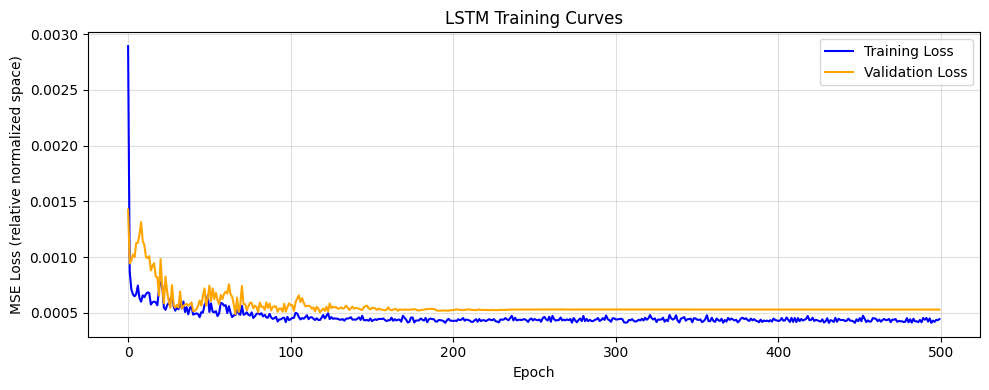

In [178]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(val_losses,   label='Validation Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (relative normalized space)')
plt.title('LSTM Training Curves')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('../results/training_curves.png', dpi=150)
plt.show()

### Evaluate
Loading the best saved model and compute predictions in absolute metres.

In [179]:
model.load_state_dict(torch.load('../models/lstm_best.pt', map_location=device))
model.eval()

def predict(positions_2d):
    """
    For each timestep:
      1. Subtract anchor (last known pos) → relative input
      2. Normalize → feed to model → denormalize → relative prediction
      3. Add anchor back → absolute predicted position
    """
    preds, trues = [], []
    for i in range(len(positions_2d) - W):
        anchor  = positions_2d[i + W - 1]
        win_rel = positions_2d[i:i+W] - anchor
        win_n   = norm(win_rel)
        tensor  = torch.tensor(win_n, dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            rel_pred = denorm(model(tensor).cpu().numpy()[0])
        preds.append(anchor + rel_pred)
        trues.append(positions_2d[i + W])
    return np.array(preds), np.array(trues)

pred_s, true_s = predict(pos_s)
pred_c, true_c = predict(pos_c)
pred_t, true_t = predict(pos_t)

# Manual check on first prediction
print("MANUAL CHECK")
print(f"Anchor   (pos_s[9]):  {pos_s[9]}")
print(f"True next(pos_s[10]): {pos_s[10]}")
print(f"Predicted:            {pred_s[0]}")
print(f"Error:    {np.sqrt(np.sum((pred_s[0]-true_s[0])**2)):.4f}m")

def mae(p, t):
    return np.mean(np.sqrt(np.sum((p-t)**2, axis=1)))

print(f"\nMEAN ABSOLUTE POSITION ERROR")
mae_s = mae(pred_s, true_s)
mae_c = mae(pred_c, true_c)
mae_t = mae(pred_t, true_t)
print(f"Straight : {mae_s:.4f} m  (target < 0.5m)")
print(f"Curve    : {mae_c:.4f} m")
print(f"Turn     : {mae_t:.4f} m  (target < 1.5m)")

MANUAL CHECK
Anchor   (pos_s[9]):  [260.023 313.571]
True next(pos_s[10]): [260.023 315.171]
Predicted:            [260.01486 315.09586]
Error:    0.0756m

MEAN ABSOLUTE POSITION ERROR
Straight : 0.1068 m  (target < 0.5m)
Curve    : 0.1539 m
Turn     : 0.1038 m  (target < 1.5m)


### Plot showing Predicted vs Actual Positions

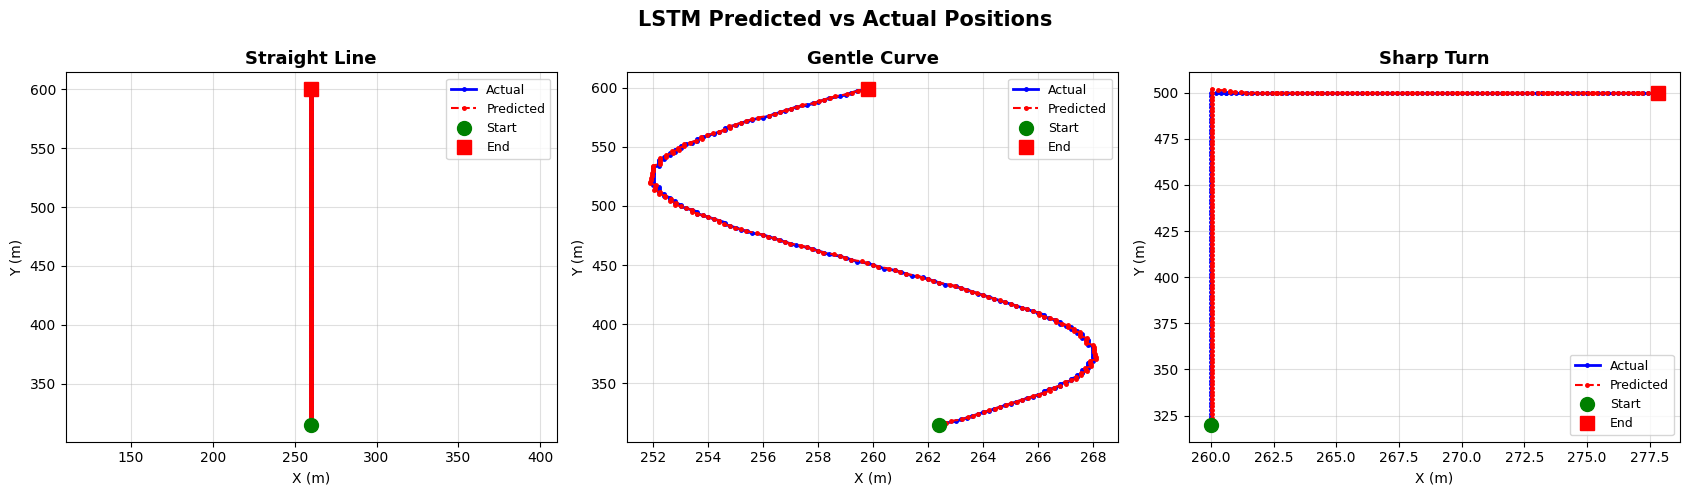

In [180]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (p, t, title) in zip(axes, [
    (pred_s, true_s, 'Straight Line'),
    (pred_c, true_c, 'Gentle Curve'),
    (pred_t, true_t, 'Sharp Turn'),
]):
    ax.plot(t[:,0], t[:,1], 'b.-', lw=2, ms=5, label='Actual')
    ax.plot(p[:,0], p[:,1], 'r.--', lw=1.5, ms=5, label='Predicted')
    ax.plot(t[0,0],  t[0,1],  'go', ms=10, label='Start')
    ax.plot(t[-1,0], t[-1,1], 'rs', ms=10, label='End')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.4)

# Fix straight line plot only — X axis was zooming in to ~0.5m range
# making a 0.02m prediction error look enormous.
# Set X range to match the Y span so the straight line looks straight.
y_span = pos_s[:,1].max() - pos_s[:,1].min()
x_mid  = np.mean(pos_s[:,0])
axes[0].set_xlim(x_mid - y_span/2, x_mid + y_span/2)

plt.suptitle('LSTM Predicted vs Actual Positions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/lstm_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [183]:
from IPython.display import display, HTML

for pred, true, traj_name in [
    (pred_s, true_s, 'Straight Line'),
    (pred_c, true_c, 'Gentle Curve'),
    (pred_t, true_t, 'Sharp Turn'),
]:
    indices = list(range(0, len(pred), 10))
    if indices[-1] != len(pred) - 1:
        indices.append(len(pred) - 1)

    rows_html = ''
    for idx in indices:
        err_m = np.sqrt(np.sum((pred[idx] - true[idx])**2))
        if err_m < 0.5:
            err_color = '#c8f7c5'
        elif err_m < 1.0:
            err_color = '#fef9c3'
        else:
            err_color = '#fdd5d5'
        rows_html += f"""
        <tr>
            <td style='text-align:center'>{idx}</td>
            <td style='text-align:center'>{true[idx,0]:.3f}</td>
            <td style='text-align:center'>{true[idx,1]:.3f}</td>
            <td style='text-align:center'>{pred[idx,0]:.3f}</td>
            <td style='text-align:center'>{pred[idx,1]:.3f}</td>
            <td style='text-align:center; background-color:{err_color}'>{err_m:.4f}</td>
        </tr>"""

    html = f"""
    <h3 style='font-family:sans-serif; margin-top:30px'>
        📍 {traj_name} &nbsp;
        <span style='font-size:13px; font-weight:normal; color:#555'>
            All values in metres (m)
        </span>
    </h3>
    <p style='font-family:sans-serif; font-size:12px; color:#555'>
        🟢 Error &lt; 0.5m &nbsp;|&nbsp; 🟡 Error 0.5–1.0m &nbsp;|&nbsp; 🔴 Error &gt; 1.0m
    </p>
    <table style='border-collapse:collapse; font-family:sans-serif; font-size:13px; width:70%'>
        <thead>
            <tr style='background-color:#2c3e50; color:white'>
                <th style='padding:8px 14px'>Timestep</th>
                <th style='padding:8px 14px'>Actual X (m)</th>
                <th style='padding:8px 14px'>Actual Y (m)</th>
                <th style='padding:8px 14px'>Predicted X (m)</th>
                <th style='padding:8px 14px'>Predicted Y (m)</th>
                <th style='padding:8px 14px'>Error (m)</th>
            </tr>
        </thead>
        <tbody>{rows_html}</tbody>
    </table>"""

    display(HTML(html))

Timestep,Actual X (m),Actual Y (m),Predicted X (m),Predicted Y (m),Error (m)
0,260.023,315.171,260.015,315.096,0.0756
10,260.023,330.171,260.015,330.078,0.0932
20,260.023,345.171,260.015,345.299,0.1284
30,260.023,360.371,260.015,360.289,0.0827
40,260.023,375.371,260.015,375.278,0.0932
50,260.023,390.371,260.015,390.496,0.1251
60,260.023,405.571,260.015,405.485,0.0867
70,260.023,420.571,260.015,420.707,0.1364
80,260.023,435.771,260.015,435.696,0.0756
90,260.023,450.771,260.015,450.678,0.0932


Timestep,Actual X (m),Actual Y (m),Predicted X (m),Predicted Y (m),Error (m)
0,262.423,314.971,262.450,315.318,0.3478
10,264.623,329.971,264.631,330.274,0.3034
20,266.423,344.971,266.399,345.219,0.2491
30,267.623,359.971,267.769,360.163,0.2418
40,268.023,374.971,268.070,375.104,0.1409
50,267.623,389.971,267.520,390.113,0.1757
60,266.423,404.971,266.445,405.124,0.1547
70,264.623,419.971,264.609,420.128,0.1574
80,262.423,434.971,262.398,435.127,0.1578
90,260.023,449.971,259.996,450.124,0.1556


Timestep,Actual X (m),Actual Y (m),Predicted X (m),Predicted Y (m),Error (m)
0,260.023,319.971,260.029,319.910,0.0616
10,260.023,339.971,260.029,339.910,0.0616
20,260.023,359.971,260.029,359.910,0.0616
30,260.023,379.971,260.029,379.910,0.0616
40,260.023,399.971,260.029,399.910,0.0616
50,260.023,419.971,260.029,419.910,0.0616
60,260.023,439.971,260.029,439.910,0.0616
70,260.023,459.971,260.029,459.910,0.0616
80,260.023,479.971,260.029,479.910,0.0616
90,260.023,499.971,260.029,499.910,0.0616


### Trajectory 3: Zoomed in at Turning Point

pred_t length: 190
Turn happens at timestep: 95
Zooming into timesteps 80 to 110
t_zoom shape: (30, 2)
p_zoom shape: (30, 2)


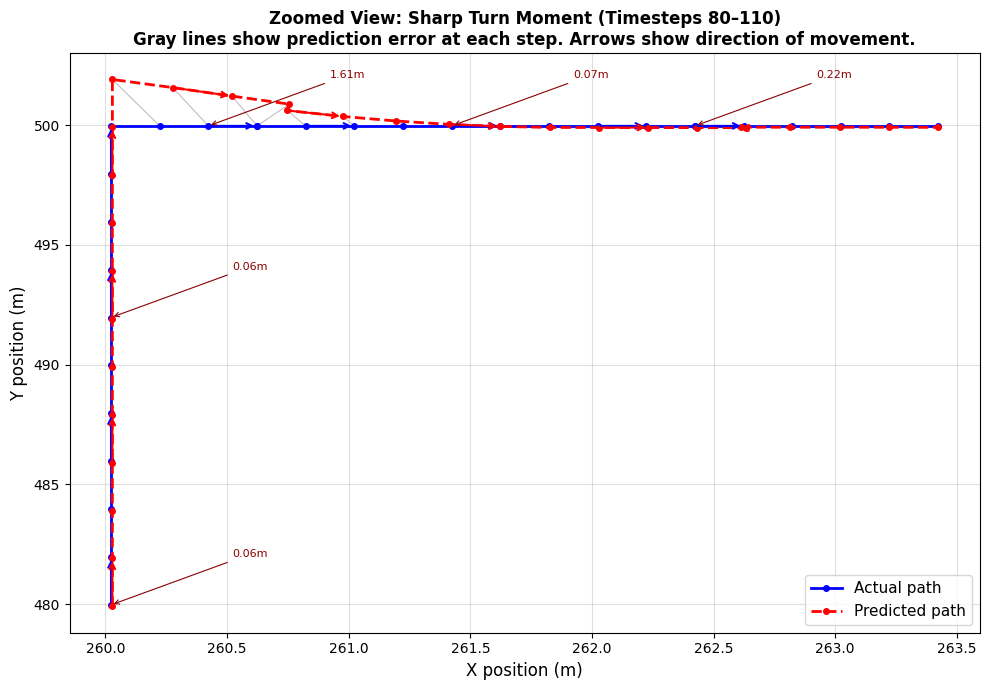

In [196]:
# Auto-detect correct zoom range based on actual data length
print(f"pred_t length: {len(pred_t)}")
print(f"Turn happens at timestep: {len(pred_t)//2}")

# Turn happens at the midpoint of the trajectory (100 steps straight, 100 steps horizontal)
# In prediction space (190 windows), turn is at index ~90
turn_ts   = len(pred_t) // 2
zoom_start = max(0, turn_ts - 15)
zoom_end   = min(len(pred_t), turn_ts + 15)

print(f"Zooming into timesteps {zoom_start} to {zoom_end}")

t_zoom = true_t[zoom_start:zoom_end]
p_zoom = pred_t[zoom_start:zoom_end]

print(f"t_zoom shape: {t_zoom.shape}")
print(f"p_zoom shape: {p_zoom.shape}")

fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(t_zoom[:,0], t_zoom[:,1], 'b.-', lw=2, ms=8, label='Actual path', zorder=3)
ax.plot(p_zoom[:,0], p_zoom[:,1], 'r.--', lw=2, ms=8, label='Predicted path', zorder=3)

# Add movement arrows every 3 steps
for i in range(0, len(t_zoom)-3, 3):
    ax.annotate('',
        xy=(t_zoom[i+1,0], t_zoom[i+1,1]),
        xytext=(t_zoom[i,0], t_zoom[i,1]),
        arrowprops=dict(arrowstyle='->', color='blue', lw=1.5))
    ax.annotate('',
        xy=(p_zoom[i+1,0], p_zoom[i+1,1]),
        xytext=(p_zoom[i,0], p_zoom[i,1]),
        arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

# Draw error lines between prediction and truth at each step
for i in range(len(t_zoom)):
    ax.plot([t_zoom[i,0], p_zoom[i,0]],
            [t_zoom[i,1], p_zoom[i,1]],
            color='gray', lw=0.8, alpha=0.5, zorder=1)

# Mark the turn point (middle of zoom window)
mid = len(t_zoom) // 2
#ax.plot(t_zoom[mid,0], t_zoom[mid,1], 'k*', ms=18, zorder=5, label='Turn moment')

# Annotate error values at a few points
for i in range(0, len(t_zoom), max(1, len(t_zoom)//5)):
    err_i = np.sqrt(np.sum((p_zoom[i]-t_zoom[i])**2))
    ax.annotate(f'{err_i:.2f}m',
        xy=(t_zoom[i,0], t_zoom[i,1]),
        xytext=(t_zoom[i,0]+0.5, t_zoom[i,1]+2),
        fontsize=8, color='darkred',
        arrowprops=dict(arrowstyle='->', color='darkred', lw=0.8))

ax.set_xlabel('X position (m)', fontsize=12)
ax.set_ylabel('Y position (m)', fontsize=12)
ax.set_title(f'Zoomed View: Sharp Turn Moment (Timesteps {zoom_start}–{zoom_end})\n'
             'Gray lines show prediction error at each step. '
             'Arrows show direction of movement.',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('../results/turn_zoom.png', dpi=150, bbox_inches='tight')
plt.show()

### Plot: Prediction Error Over Time

Per-trajectory error statistics:
  Straight — mean: 0.107m  max: 0.140m
  Curve    — mean: 0.154m  max: 0.375m
  Turn     — mean: 0.104m  max: 1.948m


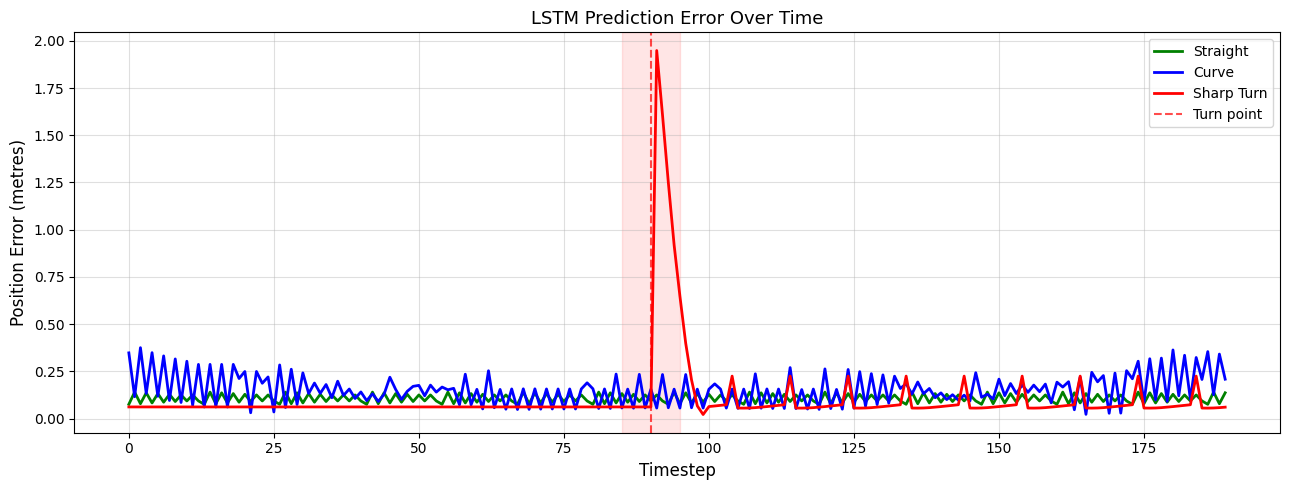

In [194]:
def err(p, t): return np.sqrt(np.sum((p-t)**2, axis=1))
es = err(pred_s, true_s)
ec = err(pred_c, true_c)
et = err(pred_t, true_t)

print("Per-trajectory error statistics:")
print(f"  Straight — mean: {es.mean():.3f}m  max: {es.max():.3f}m")
print(f"  Curve    — mean: {ec.mean():.3f}m  max: {ec.max():.3f}m")
print(f"  Turn     — mean: {et.mean():.3f}m  max: {et.max():.3f}m")

plt.figure(figsize=(13, 5))
plt.plot(es, color='green', lw=2, label='Straight')
plt.plot(ec, color='blue',  lw=2, label='Curve')
plt.plot(et, color='red',   lw=2, label='Sharp Turn')
plt.axvline(x=90, color='red', ls='--', alpha=0.7, lw=1.5, label='Turn point')
plt.axvspan(85, 95, alpha=0.1, color='red')
plt.xlabel('Timestep', fontsize=12)
plt.ylabel('Position Error (metres)', fontsize=12)
plt.title('LSTM Prediction Error Over Time', fontsize=13)
plt.legend(fontsize=10); plt.grid(True, alpha=0.4); plt.tight_layout()
plt.savefig('../results/prediction_error_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

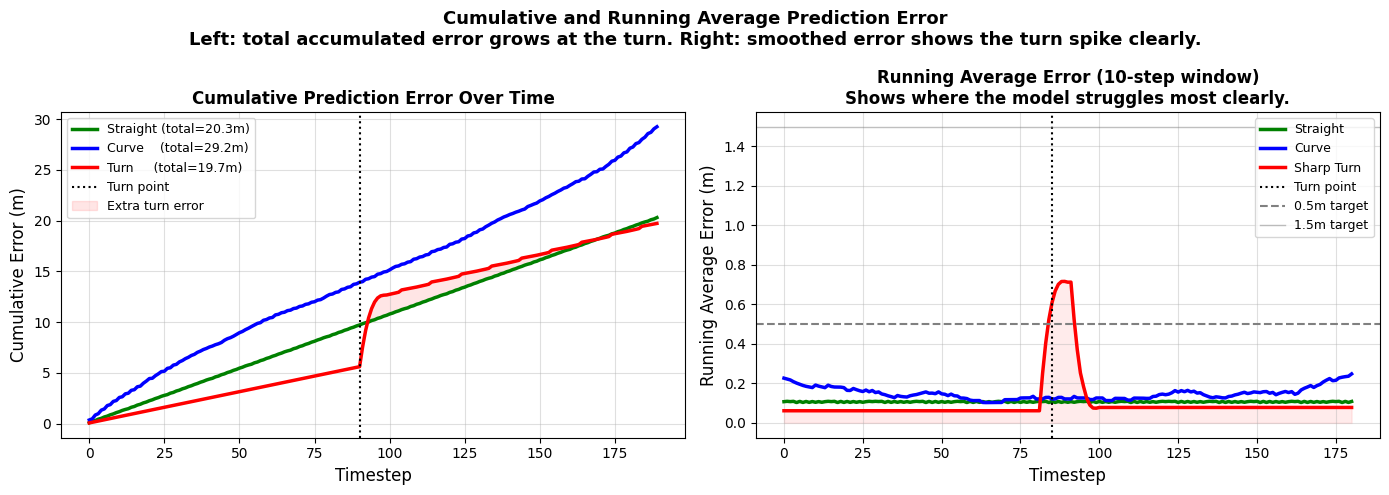

In [197]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

es_cum = np.cumsum(es)
ec_cum = np.cumsum(ec)
et_cum = np.cumsum(et)
steps  = np.arange(len(es))

# Left: cumulative error
axes[0].plot(steps, es_cum, color='green', lw=2.5, label=f'Straight (total={es_cum[-1]:.1f}m)')
axes[0].plot(steps, ec_cum, color='blue',  lw=2.5, label=f'Curve    (total={ec_cum[-1]:.1f}m)')
axes[0].plot(steps, et_cum, color='red',   lw=2.5, label=f'Turn     (total={et_cum[-1]:.1f}m)')
axes[0].axvline(x=90, color='black', ls=':', lw=1.5, label='Turn point')
axes[0].fill_between(steps, et_cum, es_cum,
                     where=(et_cum > es_cum), alpha=0.1, color='red',
                     label='Extra turn error')
axes[0].set_xlabel('Timestep', fontsize=12)
axes[0].set_ylabel('Cumulative Error (m)', fontsize=12)
axes[0].set_title('Cumulative Prediction Error Over Time', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.4)

# Right: running average error (smoothed)
window_avg = 10
es_avg = np.convolve(es, np.ones(window_avg)/window_avg, mode='valid')
ec_avg = np.convolve(ec, np.ones(window_avg)/window_avg, mode='valid')
et_avg = np.convolve(et, np.ones(window_avg)/window_avg, mode='valid')
steps_avg = np.arange(len(es_avg))

axes[1].plot(steps_avg, es_avg, color='green', lw=2.5, label='Straight')
axes[1].plot(steps_avg, ec_avg, color='blue',  lw=2.5, label='Curve')
axes[1].plot(steps_avg, et_avg, color='red',   lw=2.5, label='Sharp Turn')
axes[1].axvline(x=85, color='black', ls=':', lw=1.5, label='Turn point')
axes[1].axhline(0.5,  color='gray',  ls='--', lw=1.5, label='0.5m target')
axes[1].axhline(1.5,  color='gray',  ls='-',  lw=1.0, alpha=0.5, label='1.5m target')
axes[1].fill_between(steps_avg, et_avg, 0, alpha=0.08, color='red')
axes[1].set_xlabel('Timestep', fontsize=12)
axes[1].set_ylabel('Running Average Error (m)', fontsize=12)
axes[1].set_title(f'Running Average Error ({window_avg}-step window)\n'
                  'Shows where the model struggles most clearly.',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.4)

fig.suptitle('Cumulative and Running Average Prediction Error\n'
             'Left: total accumulated error grows at the turn. '
             'Right: smoothed error shows the turn spike clearly.',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/cumulative_error.png', dpi=150, bbox_inches='tight')
plt.show()